<a href="https://colab.research.google.com/github/D2718281828nis/Neuro-Neuronal_dynamics/blob/master/GCN%E2%80%93Hindmarsh%E2%80%93Rose-EEG-4-Attention-Stability-Index.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GCN–Hindmarsh–Rose EEG model: calibrated Attention Stability Index

This version adds nonstationary neural rhythms, theta–gamma phase–amplitude coupling, parameter calibration for the requested attention-load profile, and graph visualization with guaranteed visible functional edges. ASI remains a proposed research metric, not a validated clinical biomarker.


> source for realistic EEG signal
https://onlinelibrary.wiley.com/doi/epdf/10.1155/2021/5229576$0



# Пояснение к модели

## 1. Назначение модели

Код реализует вычислительный эксперимент, предназначенный для исследования следующей гипотезы:

> Ограничение внимания может проявляться не как нехватка активности отдельных нейронов, а как потеря устойчивой пространственно-временной организации распределённой нейронной сети при увеличении числа одновременно поддерживаемых объектов.

Модель объединяет четыре уровня описания:

1. динамику отдельных нейронов;
2. динамику нейронных ансамблей;
3. пространственную структуру взаимодействия ансамблей;
4. макроскопические EEG-подобные ритмы и функциональную связность.

Общая вычислительная цепочка:

```text
Нейроны Хиндмарша–Розе
        ↓
Нейронные ансамбли
        ↓
Гиппокампально-таламо-кортикальный граф
        ↓
GCN-регуляция межансамблевых связей
        ↓
Виртуальный многоканальный EEG
        ↓
Спектральные и сетевые EEG-признаки
        ↓
Attention Stability Index
```

Модель не претендует на анатомически точное воспроизведение мозга. Это мезоскопическая имитационная модель, предназначенная для проверки принципа: может ли ограничение внимания возникать как граница устойчивости сложной динамической сети.

---

## 2. Что считается объектом внимания

Каждый объект внимания представлен одним целевым кортикальным ансамблем.

При нагрузке:

```python
load = 1
```

активируется один кортикальный ансамбль.

При:

```python
load = 4
```

одновременно целевыми становятся четыре ансамбля.

При дальнейшем увеличении `load` модель должна перейти из режима устойчивой селективной обработки в режим перегрузки.

Таким образом, `load` — не количество нейронов и не количество EEG-каналов. Это количество одновременно поддерживаемых нейронных представлений.

---

## 3. Пространственная структура модели

Функция:

```python
build_brain_graph()
```

строит граф трёх типов узлов.

### 3.1. Гиппокампальный узел

```text
HPC
```

Гиппокамп в модели трактуется как контекстный оркестратор памяти.

Это не означает, что гиппокамп объявляется единственным центром памяти или внимания. В рамках модели он выполняет инженерную функцию:

* получает информацию о текущей нагрузке;
* участвует в координации целевых ансамблей;
* связан с таламическими реле;
* способствует поддержанию распределённого контекста.

При увеличении нагрузки входной ток гиппокампального узла немного возрастает:

```python
base_current[hippocampus] += min(load, 10) * 0.018
```

То есть модель предполагает, что поддержание большего количества объектов требует усиления контекстной координации.

### 3.2. Таламические узлы

```text
TH_0, TH_1, TH_2, TH_3
```

Таламические узлы выступают в роли реле между гиппокампальным и кортикальными ансамблями.

Вес гиппокампально-таламической связи:

```python
weight = 1.00
```

Вес таламо-кортикальной связи:

```python
weight = 0.95
```

### 3.3. Кортикальные узлы

```text
CTX_0 ... CTX_19
```

Кортикальные узлы представляют ансамбли, потенциально способные кодировать объекты внимания.

Между ними дополнительно создаются разреженные связи:

```python
p_cortical = 0.12
weight = 0.20
```

Поэтому граф состоит из:

* относительно сильной гиппокампально-таламо-кортикальной основы;
* более слабой распределённой кортико-кортикальной сети.

---

## 4. Что находится внутри узла

Каждый узел графа — это не один искусственный нейрон, а ансамбль нейронов Хиндмарша–Розе.

В демонстрационном запуске:

```python
neurons_per_ensemble = 8
```

Каждый нейрон описывается системой:

$\dot{x} = y - a x^3 + b x^2 - z + I$


$\dot{y} = c-dx^2-y$


$\dot{z} = r\left[s(x-x_R)-z\right]$


Здесь:

* (x) — быстрая переменная, интерпретируемая как мембранный потенциал;
* (y) — быстрая восстановительная переменная;
* (z) — медленная адаптационная переменная;
* (I) — совокупный входной ток.

Используемые параметры:

```python
a = 1.0
b = 3.0
c = 1.0
d = 5.0
r = 0.006
s = 4.0
x_rest = -1.6
```

Модель Хиндмарша–Розе позволяет получить:

* одиночные spikes;
* пачечную bursting-активность;
* переходы между регулярными и сложными режимами;
* чувствительность к входному току и межнейронной связи.

Численное интегрирование выполняется методом Хойна, то есть схемой predictor–corrector. Она устойчивее простого явного метода Эйлера.

---

## 5. Как определяется spike

Spike фиксируется при пересечении переменной (x) нулевого порога снизу вверх:

```python
spikes = (prev_x < 0.0) & (x >= 0.0)
```

Затем для каждого ансамбля рассчитывается средняя частота пересечений:

```python
spike_history[t] = spikes.mean(axis=1) / dt
```

Это даёт population firing rate для каждого узла графа.

Спайковая активность используется в двух местах:

1. для оценки состояния ансамбля;
2. как вход GCN-контроллера, регулирующего межансамблевое взаимодействие.

---

## 6. Роль GCN

GCN в данной модели не распознаёт EEG и не предсказывает внимание напрямую.

Его функция — адаптивно управлять коэффициентами межансамблевой связи.

Для каждого ансамбля GCN получает признаки:

```text
rate
rate variability
local synchrony
target flag
HPC role
thalamus role
cortex role
normalized load
```

На выходе формируется коэффициент:

[
g_i\in[0.35,1.35].
]

Он входит в графовый ток:

[
I_i^{graph}
===========

\kappa g_i
\left(
\sum_j A_{ij}\bar{x}_j
----------------------

\sum_j A_{ij}\bar{x}_i
\right).
]

По смыслу GCN регулирует, насколько сильно каждый ансамбль должен следовать активности соседних узлов.

### При низкой нагрузке

GCN старается:

* поддерживать целевые кортикальные ансамбли;
* сохранять работу таламических реле;
* удерживать гиппокампальный узел активным;
* подавлять нерелевантный фон.

### При перегрузке

GCN уменьшает усиление:

* фоновых ансамблей;
* чрезмерно синхронизированных узлов;
* ансамблей с нестабильной активностью.

Важно, что GCN обучается не на реальных EEG-данных, а на синтетическом эвристическом учителе.

Следовательно, GCN в этой реализации — часть сформулированной гипотезы, а не обученная биологическая модель внимания.

---

## 7. Переход от нейронной активности к виртуальному EEG

Функция:

```python
virtual_eeg()
```

создаёт многоканальный EEG-подобный сигнал.

Сначала из активности HR-ансамбля строится нелинейный носитель:

[
HR_i(t)
=======

0.82\bar{x}_i(t)
+
0.05\frac{d\bar{x}_i(t)}{dt}
+
0.13\tanh\left(\frac{R_i(t)}4\right).
]

После нормализации он умножается на:

```python
hr_weight = 0.36
```

Затем к HR-компоненту добавляются синтетические ритмы:

* delta;
* theta;
* alpha;
* beta;
* gamma.

Итог:

[
EEG_i(t)
========

w_{HR}HR_i(t)
+
D_i(t)
+
\Theta_i(t)
+
A_i(t)
+
B_i(t)
+
\Gamma_i(t)
+
\eta_i(t).
]

Ритмы имеют медленно меняющуюся частоту, поэтому сигнал не является простой суммой строго стационарных синусоид.

---

## 8. Амплитуды EEG в основной модели

В функции `virtual_eeg()` используются нормированные модельные амплитуды:

```python
theta_base     = 0.34
theta_peak     = 0.34
alpha_bg       = 0.34
alpha_target   = 0.13
beta_target    = 0.34
gamma_target   = 0.20
pac_strength   = 0.24
hr_weight      = 0.36
```

Эти значения не являются микровольтами.

Они задают относительный вклад компонентов до итоговой поканальной нормализации:

```python
eeg /= median(abs(eeg))
```

Поэтому в основной функции важны не абсолютные числа, а отношения амплитуд.

### 8.1. Alpha

Для целевого ансамбля:

```python
alpha_target = 0.13
```

Для фонового:

```python
alpha_bg = 0.34
```

То есть:

[
A_{\alpha}^{background}

>

A_{\alpha}^{target}.
]

Это соответствует заложенной интерпретации alpha gating:

* повышенная alpha в нерелевантных областях означает подавление;
* сниженная alpha в целевой области означает функциональный доступ к обработке.

Именно такое отношение согласовано с формулой компонента `alpha_gating`.

### 8.2. Beta

Для цели:

```python
beta_target = 0.34
```

Для фона:

```python
beta_background = 0.10
```

Beta усиливает различие между целевыми и фоновыми ансамблями.

### 8.3. Gamma

Для цели:

```python
gamma_target = 0.20
```

Для фона:

```python
gamma_background = 0.06
```

Gamma дополнительно поддерживает локальную селективность целевого представления.

### 8.4. Theta

Theta-амплитуда зависит от нагрузки:

[
A_{\theta}(L)
=============

\theta_{base}
+
\theta_{peak}
\exp
\left[
------

\left(
\frac{L-2.5}{1.25}
\right)^2
\right].
]

Она максимальна приблизительно при двух-трёх объектах.

Это реализует гипотезу:

> Для одного объекта сложная распределённая маршрутизация ещё не требуется. При двух-трёх объектах координационная роль theta возрастает. После дальнейшего роста нагрузки полезная координация переходит в интерференцию.

Дополнительно theta зависит от роли узла:

```python
HPC       × 1.10
thalamus  × 0.92
cortex    × 0.62
```

Поэтому theta сильнее выражена в гиппокампальном и таламических узлах.

---

## 9. Уточнённые абсолютные амплитуды

В конце notebook добавлена отдельная функция:

```python
_raw_virtual_eeg()
```

В ней используются другие амплитуды:

```python
theta_amp    = 20.0
alpha_bg     = 10.0
alpha_target = 40.0
beta_target  = 10.0
gamma_target = 4.0
beta_bg      = 1.5
gamma_bg     = 0.5
delta_amp    = 5.0
pac_strength = 0.5
```

Эта функция не нормирует итоговый сигнал и предназначена для визуализации относительных амплитуд.

Однако здесь есть принципиальное различие с основной моделью.

В основной функции:

```text
alpha background > alpha target
```

В raw-функции:

```text
alpha target > alpha background
```

То есть направление alpha gating перевёрнуто.

При этом ASI вычисляется не по `_raw_virtual_eeg()`, а по `virtual_eeg()`.

Следовательно:

> Уточнённые абсолютные амплитуды из `_raw_virtual_eeg()` не влияют на рассчитанный ASI.

Они влияют только на нижний график raw EEG.

Это означает, что сейчас в notebook фактически существуют две разные модели амплитуд:

| Компонент        | Модель ASI | Raw-визуализация |
| ---------------- | ---------: | ---------------: |
| Alpha target     |       0.13 |               40 |
| Alpha background |       0.34 |               10 |
| Beta target      |       0.34 |               10 |
| Beta background  |       0.10 |              1.5 |
| Gamma target     |       0.20 |                4 |
| Gamma background |       0.06 |              0.5 |

Для научной интерпретации их нельзя считать одной и той же параметризацией.

### Вывод по уточнённым амплитудам

Абсолютные значения `40`, `20`, `10`, `5` и `4` могут быть использованы как условные микровольтовые амплитуды для наглядной иллюстрации.

Но перед публикацией необходимо выбрать один из вариантов:

1. использовать raw-амплитуды только как независимую демонстрацию формы EEG;
2. перенести их отношения в основную функцию `virtual_eeg()`;
3. рассчитывать ASI непосредственно из raw EEG;
4. привести raw-амплитуды к той же логике alpha gating, что используется в ASI.

В текущем виде утверждение «ASI рассчитан с использованием уточнённых амплитуд» будет некорректным.

---

## 10. Theta–gamma phase–amplitude coupling

Gamma-амплитуда модулируется фазой theta:

[
A_{\gamma}(t)
=============

0.35+
k_{PAC}
\frac{1+\sin\phi_{\theta}(t)}2.
]

Gamma-компонент:

[
\Gamma(t)
=========

A_{\gamma}(t)\sin\phi_{\gamma}(t).
]

Таким образом, gamma-bursts возникают преимущественно в определённые фазы theta.

Это используется как модель возможной временной упаковки локальной быстрой обработки в более медленный координационный ритм.

В коде этот механизм реализован для каждого узла, но не рассчитывается как отдельный компонент ASI. ASI учитывает его косвенно через:

* спектральную мощность gamma;
* spatial selectivity;
* spectral entropy;
* временную стабильность.

---

## 11. Как моделируется перегрузка

Перегрузка начинается после четырёх объектов:

```python
overload = max(0.0, (load - 4) / 4.0)
```

При перегрузке добавляются два эффекта.

### 11.1. Общий theta-подобный сигнал

```python
common = sin(2π × 6.2 × t + phase)
```

Он одновременно добавляется всем каналам.

Это увеличивает общесетевую фазовую согласованность.

### 11.2. Broadband noise

```python
overload_noise * overload * random_noise
```

Шум снижает:

* спектральную упорядоченность;
* временную стабильность;
* различимость отдельных представлений.

Таким образом, модель допускает два варианта перегрузки:

1. чрезмерная глобальная синхронизация;
2. дезорганизация и рост шума.

---

## 12. Функциональный EEG-граф

Анатомический граф задаётся заранее.

Функциональный граф вычисляется по виртуальному EEG с помощью Phase Locking Value:

[
PLV_{ij}
========

\left|
\frac1T
\sum_t
e^{i(\phi_i(t)-\phi_j(t))}
\right|.
]

PLV показывает, насколько постоянна разность фаз между двумя каналами.

В визуализации:

```text
пунктирные серые рёбра = структурная сеть;
сплошные синие рёбра = функциональная PLV-сеть.
```

Для каждого узла сохраняются три сильнейшие функциональные связи:

```python
top_k = 3
```

Поэтому функциональные рёбра видны даже тогда, когда абсолютные PLV малы.

Толщина ребра отражает относительную силу связи.

Важно:

> Top-k-визуализация гарантирует наличие рёбер, но не гарантирует, что эти связи статистически значимы.

Она подходит для демонстрации структуры, но для научного анализа потребуется:

* статистический порог;
* surrogate testing;
* сравнение с shuffled phases;
* либо фиксированная плотность графа для всех нагрузок.

---

## 13. Что такое Attention Stability Index

Attention Stability Index определяется как интегральная оценка того, насколько устойчиво сеть:

* поддерживает активность целевых представлений;
* отделяет их от фоновых;
* координирует распределённые области;
* подавляет нерелевантную активность;
* сохраняет сложную, но не хаотическую динамику;
* удерживает функционально эффективную сеть.

В коде:

[
ASI
===

E^{0.18}
G^{0.13}
P^{0.20}
S^{0.20}
C^{0.09}
T^{0.13}
F^{0.07}.
]

Где:

* (E) — spectral engagement;
* (G) — alpha gating;
* (P) — phase organization;
* (S) — spatial selectivity;
* (C) — spectral complexity;
* (T) — temporal stability;
* (F) — functional efficiency.

Используется взвешенное геометрическое среднее.

Это означает, что очень низкое значение одного важного компонента существенно уменьшает весь индекс.

Например:

* высокая beta сама по себе не обеспечивает высокий ASI;
* высокая синхронизация не компенсирует потерю селективности;
* хорошая функциональная эффективность не компенсирует временную нестабильность.

---

## 14. Spectral Engagement

Компонент рассчитывается по целевым ансамблям:

[
E_{raw}
=======

\frac{P_{\beta}^{target}}
{P_{\theta}^{target}+P_{\alpha}^{target}+\varepsilon}.
]

После этого применяется sigmoid-преобразование:

[
E
=

\sigma
\left[
4(E_{raw}-0.75)
\right].
]

Интерпретация:

* beta представляет поддержание текущего активного состояния;
* theta и alpha в знаменателе ограничивают оценку;
* высокая beta относительно theta и alpha трактуется как включённость целевого представления.

Это не универсальная формула внимания, а выбранная модельная характеристика.

---

## 15. Alpha Gating

[
G
=

\sigma
\left[
3
\ln
\frac{P_{\alpha}^{background}}
{P_{\alpha}^{target}+\varepsilon}
\right].
]

Если:

[
P_{\alpha}^{background}

>

P_{\alpha}^{target},
]

компонент растёт.

Интерпретация:

> Нерелевантные ансамбли сильнее подавлены alpha-активностью, чем целевые ансамбли.

Именно поэтому основная параметризация:

```python
alpha_bg = 0.34
alpha_target = 0.13
```

логически согласована с ASI.

Raw-параметризация `alpha_target=40`, `alpha_bg=10` с этой формулой не согласуется.

---

## 16. Spatial Selectivity

[
S_{raw}
=======

\frac{
(P_{\beta}+P_{\gamma})_{target}
-------------------------------

(P_{\beta}+P_{\gamma})*{background}
}{
(P*{\beta}+P_{\gamma})*{target}
+
(P*{\beta}+P_{\gamma})_{background}
+\varepsilon
}.
]

После sigmoid-преобразования получается (S).

Компонент отвечает на вопрос:

> Можно ли по пространственному распределению быстрой активности отличить целевые ансамбли от остальных?

Если beta/gamma одинаково сильны во всей сети, селективность низкая.

---

## 17. Phase Organization

Phase organization объединяет:

1. априорную зависимость от нагрузки;
2. измеренный theta-PLV;
3. штраф за нагрузку выше четырёх объектов;
4. штраф за чрезмерную глобальную синхронизацию.

Априорная часть:

[
P_{load}
========

\exp
\left[
------

\left(
\frac{L-2.5}{1.25}
\right)^2
\right].
]

Она заранее задаёт максимум при двух-трёх объектах.

Измеренная часть:

[
P_{measured}
============

\exp
\left[
------

\left(
\frac{PLV_{\theta}^{coord}-0.55}{0.24}
\right)^2
\right].
]

Общий компонент:

[
P
=

\left(
0.42P_{load}
+
0.58P_{measured}
\right)
P_{overload}
P_{global}.
]

Следовательно:

> Максимум phase organization при двух-трёх объектах не является независимым открытием симуляции. Он частично заложен в формулу через `load_coord`.

Симуляция может подтвердить или ослабить этот максимум через измеренный PLV, но не полностью свободна от предварительно заданной формы.

---

## 18. Spectral Complexity

Для каждого канала вычисляется нормированная спектральная энтропия:

[
H
=

*

\frac{
\sum_f p(f)\ln p(f)
}{
\ln N_f
}.
]

Затем для целевых ансамблей предпочтительным считается промежуточное значение:

[
C
=

\exp
\left[
------

\left(
\frac{H-0.62}{0.22}
\right)^2
\right].
]

Интерпретация:

* слишком низкая энтропия — чрезмерно регулярная динамика;
* слишком высокая — шумовая или дезорганизованная;
* промежуточная — сложная, но структурированная активность.

Добавленный в конце notebook граф средней энтропии показывает её изменение с нагрузкой, однако сам ASI использует энтропию только целевых каналов, а не среднее по всей сети.

---

## 19. Temporal Stability

EEG делится на четырёхсекундные перекрывающиеся окна.

Для каждого окна вычисляется:

[
R_t
===

\frac{P_{\beta}^{target}}
{P_{\theta}^{target}+P_{\alpha}^{target}+\varepsilon}.
]

После этого рассчитывается коэффициент вариации:

[
CV
==

\frac{\sigma(R_t)}
{\mu(R_t)+\varepsilon}.
]

Компонент:

[
T
=

\exp
\left(
-\frac{CV}{0.55}
\right).
]

Чем меньше временные колебания spectral engagement, тем выше temporal stability.

---

## 20. Functional Efficiency

Из alpha-PLV строится граф.

Связи с:

[
PLV<0.45
]

удаляются.

Оставшийся PLV преобразуется в расстояние:

[
d_{ij}
======

\frac1{PLV_{ij}+\varepsilon}.
]

Затем вычисляется средняя обратная длина кратчайших путей.

Компонент:

[
F
=

1-\exp(-2.2E_{graph}).
]

Он отражает способность функциональной сети обеспечивать относительно короткие пути взаимодействия.

---

## 21. Дополнительный capacity penalty

После вычисления EEG-компонентов ASI дополнительно умножается на:

[
\exp
\left[
-0.24\max(0,L-4)^{1.25}
\right].
]

При нагрузках от одного до четырёх этот коэффициент равен единице.

После четырёх объектов он принудительно снижает ASI.

Это означает:

> Падение ASI после четырёх объектов не является полностью эмерджентным результатом модели. Оно явно введено в определение индекса.

Поэтому корректная формулировка гипотезы:

> Модель исследует, согласуются ли изменения нейронной динамики и EEG-признаков с предполагаемым падением устойчивости после четырёх объектов.

Некорректная формулировка:

> Модель самостоятельно обнаружила, что мозг способен удерживать только четыре объекта.

---

## 22. Почему ASI можно содержательно интерпретировать

ASI можно трактовать как модельный индекс устойчивости внимания по трём причинам.

### 22.1. Он не сводит внимание к амплитуде одного ритма

Индекс использует одновременно:

* относительную спектральную мощность;
* alpha gating;
* фазовую координацию;
* пространственную селективность;
* спектральную сложность;
* временную устойчивость;
* топологию функциональной сети.

Это лучше соответствует представлению о внимании как о распределённом процессе.

### 22.2. Он различает активность и селективность

Высокая активность всей сети не считается устойчивым вниманием.

Для высокого ASI необходимо, чтобы целевые ансамбли отличались от фоновых.

### 22.3. Он различает полезную и патологическую синхронизацию

Нулевая координация снижает ASI.

Но и чрезмерная глобальная фазовая синхронизация также снижает ASI.

Оптимальным считается промежуточный режим:

```text
достаточная координация
+
сохранение функционального различия ансамблей
```

---

## 23. Какую гипотезу фактически проверяет код

Финальная гипотеза может быть сформулирована так:

> При увеличении числа одновременно активных представлений нейронная сеть сначала усиливает гиппокампально-таламо-кортикальную theta-координацию. При двух-трёх объектах эта координация достигает функционального максимума. До четырёх объектов сеть способна сохранять селективность и временную устойчивость. После превышения этой нагрузки усиливаются общесетевая синхронизация, спектральная интерференция и фоновая активность, вследствие чего интегральный Attention Stability Index снижается.

У гипотезы есть две части.

### Генеративная часть

Она проверяется динамикой HR-ансамблей, EEG и PLV:

* изменяются ли ритмы;
* изменяется ли фазовая связность;
* теряется ли селективность;
* растёт ли нестабильность.

### Нормативная часть

Она заранее заложена в модель:

* максимум phase organization около 2.5 объекта;
* начало overload после четырёх;
* прямой capacity penalty после четырёх.

Поэтому код представляет не чистое открытие границы, а proof of concept заранее сформулированной теории.

---

## 24. Наиболее корректная трактовка результата

Результат модели следует описывать так:

> Разработана гибридная графовая модель, объединяющая нейронные ансамбли Хиндмарша–Розе, адаптивное GCN-управление связями и виртуальный EEG. Предложенный Attention Stability Index объединяет спектральные, фазовые, пространственные, временные и графовые характеристики сигнала. В рамках заданной гипотезы модель воспроизводит режим высокой устойчивости при малом числе объектов, максимум распределённой фазовой организации при двух-трёх объектах и снижение устойчивости после превышения четырёх объектов.

Следует отдельно отметить:

> Модель демонстрирует вычислительную реализуемость гипотезы, но не доказывает универсальную ёмкость человеческого внимания.

---

## 25. Ограничения финального кода

### 25.1. Две разные EEG-параметризации

Основной ASI и raw-график используют разные отношения амплитуд.

Особенно существенно различие alpha:

```text
ASI model: alpha background > alpha target
Raw model: alpha target > alpha background
```

### 25.2. Абсолютные амплитуды не участвуют в ASI

Уточнённые значения `40`, `20`, `10`, `5`, `4` используются только в `_raw_virtual_eeg()`.

### 25.3. Предел четырёх объектов введён заранее

Он присутствует:

* в генераторе overload;
* в формуле phase organization;
* в capacity penalty;
* в функции калибровки.

### 25.4. GCN обучен на эвристической разметке

Он не прошёл обучение на реальной активности мозга.

### 25.5. Виртуальный EEG не является scalp EEG

В коде нет:

* дипольных источников;
* lead-field matrix;
* модели головы;
* референсных электродов;
* артефактов глаз и мышц;
* физически обоснованного volume conduction.

### 25.6. Обычный PLV чувствителен к volume conduction

Нулевая фазовая задержка может создавать искусственно сильные связи.

Для дальнейшей версии стоит рассмотреть:

* imaginary PLV;
* corrected imaginary PLV;
* weighted phase-lag index;
* source-space connectivity.

### 25.7. Калибровка оптимизирует ожидаемый результат

Функция `score_profile()` прямо поощряет:

* высокий ASI при одном объекте;
* максимум phase organization при двух-трёх;
* монотонное снижение после четырёх.

Поэтому grid search находит параметры под заранее заданную форму.

---

## 26. Итог

Код реализует не биологическую копию мозга, а многоуровневую исследовательскую конструкцию:

```text
нелинейная динамика нейронов
→ коллективная активность ансамблей
→ графовое взаимодействие
→ EEG-подобные ритмы
→ функциональная связность
→ интегральная устойчивость внимания
```

ASI можно интерпретировать как Attention Stability Index, потому что он оценивает не просто интенсивность активности, а одновременное выполнение нескольких условий:

* целевые представления активны;
* фон подавлен;
* сеть координирована;
* ансамбли не теряют различимость;
* ритмическая структура не становится ни чрезмерно регулярной, ни шумовой;
* состояние сохраняется во времени;
* функциональный граф остаётся эффективным.

При этом ASI остаётся авторской модельной метрикой.

Для превращения ASI в научно проверяемый EEG-индекс необходимо:

1. унифицировать амплитудную модель;
2. удалить или отдельно маркировать априорный capacity penalty;
3. провести симуляции без заранее заданного предела;
4. откалибровать веса на реальных EEG-записях;
5. использовать поведенческие показатели внимания;
6. проверить воспроизводимость на разных участниках и заданиях.


# Модель

In [ ]:
!pip -q install networkx torch

Simulating load=1 ...


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


Simulating load=2 ...


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Simulating load=3 ...
Simulating load=4 ...
Simulating load=5 ...
Simulating load=6 ...
Simulating load=7 ...
Simulating load=8 ...


/tmp/ipykernel_1756/498738330.py:704: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  den=np.trapz(pxx[total],f[total],axis=0)+1e-12
/tmp/ipykernel_1756/498738330.py:708: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  out[name]=np.trapz(pxx[m],f[m],axis=0)/den if np.any(m) else np.zeros(eeg.shape[1])


Best rhythm parameters: {'theta_peak': 0.28, 'overload_noise': 0.22, 'overload_sync': 0.16} profile loss= 0.07277043075911617


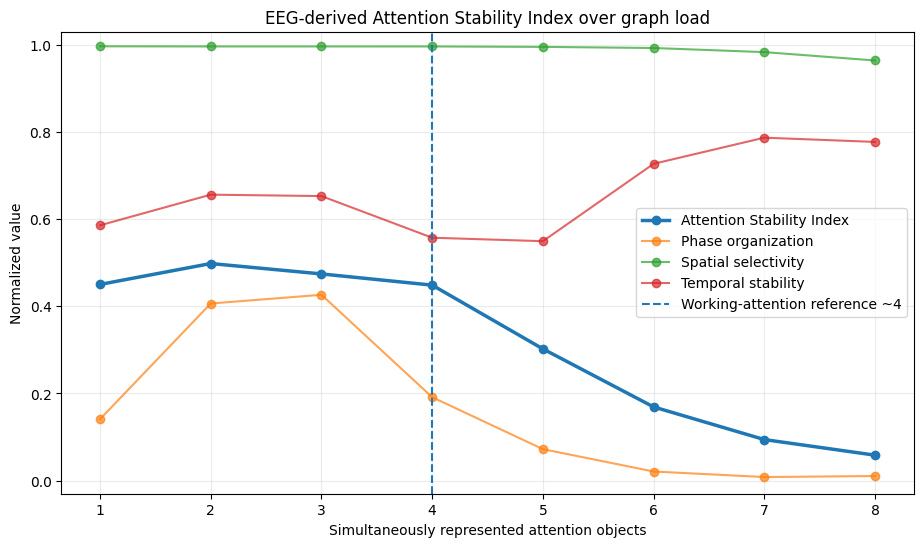

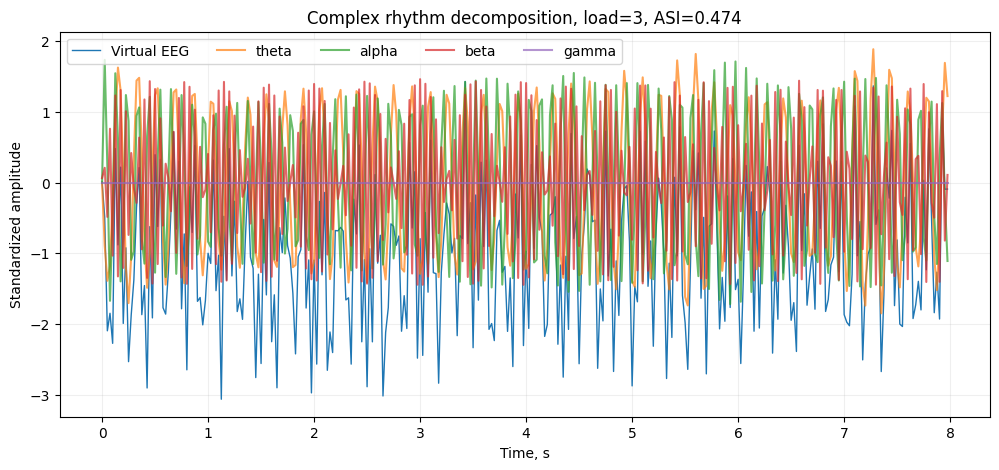

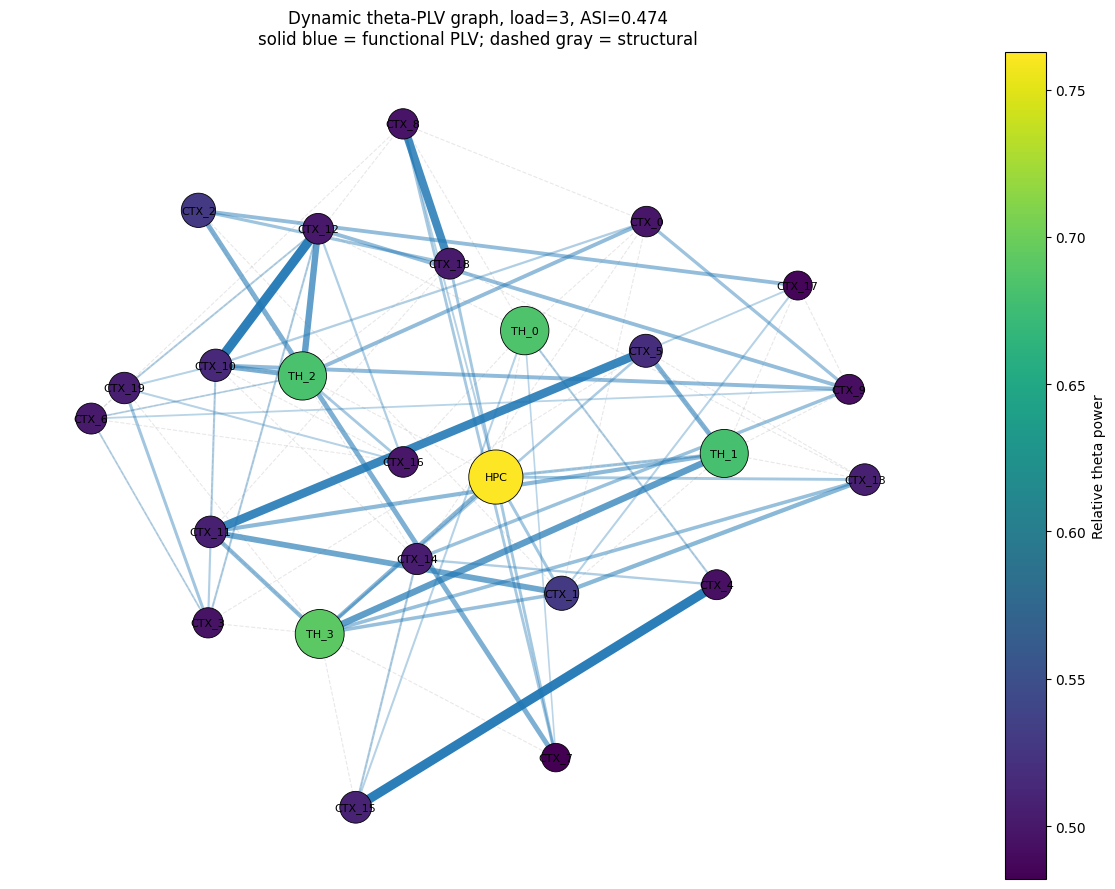

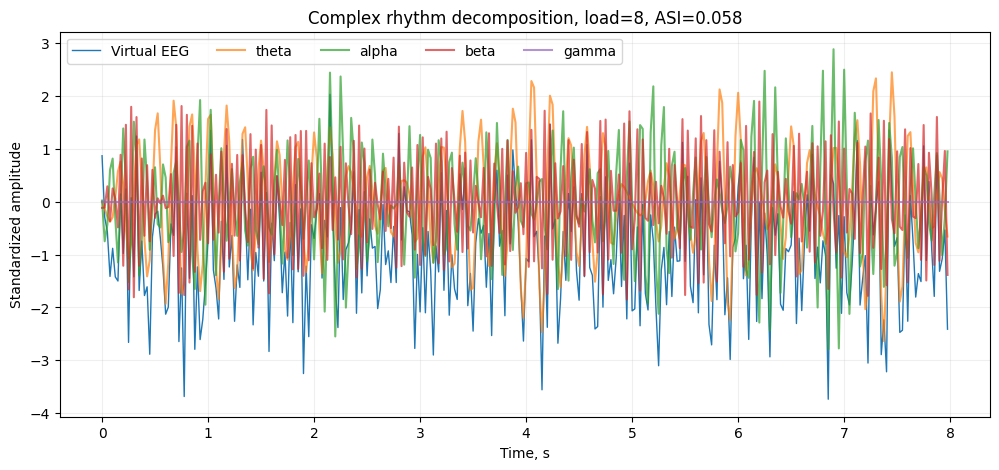

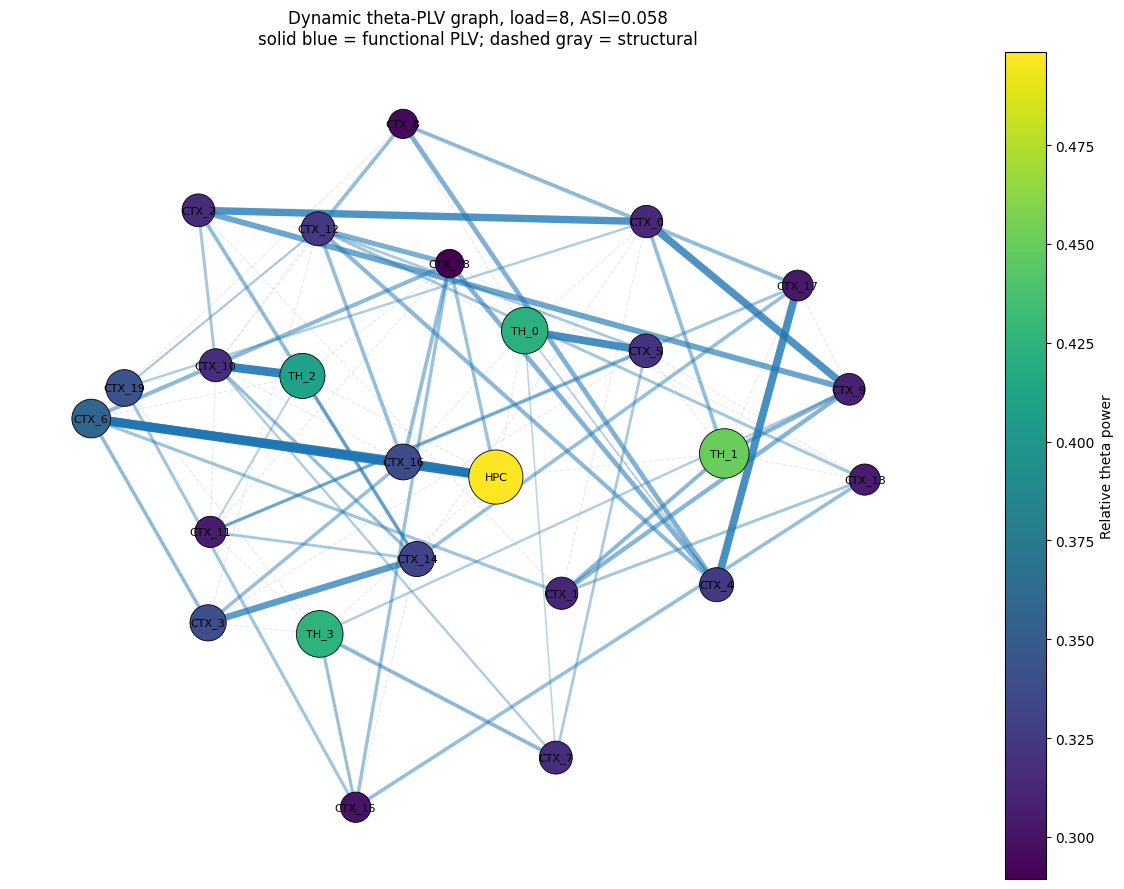

Load | ASI | phase organization | global theta PLV
   1 | 0.450 | 0.141 | 0.173
   2 | 0.498 | 0.406 | 0.175
   3 | 0.474 | 0.426 | 0.162
   4 | 0.449 | 0.191 | 0.169
   5 | 0.302 | 0.072 | 0.176
   6 | 0.169 | 0.021 | 0.151
   7 | 0.094 | 0.008 | 0.217
   8 | 0.058 | 0.011 | 0.285


In [ ]:

# GCN + Hindmarsh-Rose simulation of attention load and stability
# Google Colab compatible; dependencies: numpy, torch, matplotlib, networkx
#
# Scientific status:
# This is an illustrative mesoscopic model, not a validated biological model.
# Nodes are neural ensembles of Hindmarsh-Rose neurons.
# Edges approximate hippocampal-thalamic-cortical communication.
# A small GCN acts as an adaptive gain controller over graph messages.
#
# Attention is operationalized as:
#   1) persistent target-ensemble spiking,
#   2) separation from non-target activity,
#   3) non-pathological synchrony,
#   4) low temporal firing-rate variability.
#
# The model explores a stability boundary as the number of simultaneously
# attended objects is increased.

import math
import copy
import random
from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import networkx as nx

SEED = 7
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DT = 0.025
SPIKE_THRESHOLD = 0.0


@dataclass
class BrainGraph:
    graph: nx.Graph
    nodes: List[str]
    node_to_idx: Dict[str, int]
    roles: np.ndarray
    adjacency: np.ndarray
    normalized_adjacency: torch.Tensor
    hippocampus_idx: int
    thalamus_idx: List[int]
    cortex_idx: List[int]


def build_brain_graph(
    n_thalamus: int = 4,
    n_cortex: int = 20,
    p_cortical: float = 0.12,
) -> BrainGraph:
    """
    Roles:
      0 = hippocampus-like orchestrator
      1 = thalamic relay
      2 = cortical ensemble
    """
    G = nx.Graph()
    hpc = "HPC"
    th = [f"TH_{i}" for i in range(n_thalamus)]
    ctx = [f"CTX_{i}" for i in range(n_cortex)]

    G.add_node(hpc, role=0)
    for n in th:
        G.add_node(n, role=1)
    for n in ctx:
        G.add_node(n, role=2)

    # Hippocampal-thalamic links
    for t in th:
        G.add_edge(hpc, t, weight=1.00, pathway="hippocampal-thalamic")

    # Thalamo-cortical relays
    for i, c in enumerate(ctx):
        t = th[i % n_thalamus]
        G.add_edge(t, c, weight=0.95, pathway="thalamo-cortical")

    # Sparse cortico-cortical interactions
    for i in range(n_cortex):
        for j in range(i + 1, n_cortex):
            if np.random.rand() < p_cortical:
                G.add_edge(ctx[i], ctx[j], weight=0.20, pathway="cortico-cortical")

    nodes = list(G.nodes())
    node_to_idx = {n: i for i, n in enumerate(nodes)}
    roles = np.array([G.nodes[n]["role"] for n in nodes], dtype=np.int64)

    A = np.zeros((len(nodes), len(nodes)), dtype=np.float32)
    for u, v, data in G.edges(data=True):
        i, j = node_to_idx[u], node_to_idx[v]
        A[i, j] = data["weight"]
        A[j, i] = data["weight"]

    # GCN normalization with self-loops
    A_hat = A + np.eye(len(nodes), dtype=np.float32)
    degree = np.sum(A_hat, axis=1)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(degree + 1e-8))
    A_norm = D_inv_sqrt @ A_hat @ D_inv_sqrt

    return BrainGraph(
        graph=G,
        nodes=nodes,
        node_to_idx=node_to_idx,
        roles=roles,
        adjacency=A,
        normalized_adjacency=torch.tensor(A_norm, dtype=torch.float32, device=DEVICE),
        hippocampus_idx=node_to_idx[hpc],
        thalamus_idx=[node_to_idx[n] for n in th],
        cortex_idx=[node_to_idx[n] for n in ctx],
    )


class GCNController(nn.Module):
    """
    Adaptive graph controller.

    Input features per ensemble:
      [rate, rate_variability, local_synchrony, target_flag, role_HPC,
       role_TH, role_CTX, normalized_load]

    Outputs:
      gain in [0.35, 1.35], controlling how strongly each ensemble receives
      graph-mediated current.

    The controller is trained against a heuristic teacher:
      - preserve gain for targets,
      - reduce gain for non-targets as global load/synchrony rises,
      - keep hippocampal and thalamic relay gains active but bounded.
    """
    def __init__(self, in_dim: int = 8, hidden_dim: int = 16):
        super().__init__()
        self.lin1 = nn.Linear(in_dim, hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, 1)

    def forward(self, x: torch.Tensor, a_norm: torch.Tensor) -> torch.Tensor:
        h = a_norm @ x
        h = torch.tanh(self.lin1(h))
        h = a_norm @ h
        raw = self.lin2(h).squeeze(-1)
        return 0.35 + torch.sigmoid(raw)  # [0.35, 1.35]


def train_controller(controller: GCNController, brain: BrainGraph, epochs: int = 700) -> None:
    """
    Fast synthetic pretraining. This makes the GCN controller interpretable and
    avoids using arbitrary random GCN outputs in the dynamical simulation.
    """
    controller.train()
    optimizer = torch.optim.Adam(controller.parameters(), lr=3e-3)
    role_one_hot = np.eye(3, dtype=np.float32)[brain.roles]

    for epoch in range(epochs):
        load = np.random.randint(1, min(13, len(brain.cortex_idx) + 1))
        target_nodes = set(np.random.choice(brain.cortex_idx, size=load, replace=False).tolist())

        rates = np.random.beta(2.0, 4.0, len(brain.nodes)).astype(np.float32)
        variability = np.random.beta(2.0, 5.0, len(brain.nodes)).astype(np.float32)
        local_sync = np.random.beta(2.0, 3.0, len(brain.nodes)).astype(np.float32)

        # Higher load creates a tendency toward high background rate/synchrony.
        overload = max(0.0, (load - 4) / 8.0)
        rates += overload * np.random.uniform(0.05, 0.30, len(brain.nodes))
        local_sync += overload * np.random.uniform(0.05, 0.35, len(brain.nodes))
        rates = np.clip(rates, 0.0, 1.0)
        local_sync = np.clip(local_sync, 0.0, 1.0)

        target_flag = np.array(
            [1.0 if i in target_nodes else 0.0 for i in range(len(brain.nodes))],
            dtype=np.float32,
        )
        load_feature = np.full(len(brain.nodes), load / 12.0, dtype=np.float32)

        features = np.column_stack(
            [rates, variability, local_sync, target_flag, role_one_hot, load_feature]
        )
        x = torch.tensor(features, dtype=torch.float32, device=DEVICE)

        # Heuristic target controller:
        # target cortical ensembles stay open;
        # non-target cortical ensembles are gated under overload;
        # relay/orchestrator nodes remain moderately active.
        teacher = np.full(len(brain.nodes), 0.78, dtype=np.float32)
        for i in range(len(brain.nodes)):
            role = brain.roles[i]
            if role == 0:
                teacher[i] = 1.05 - 0.18 * overload
            elif role == 1:
                teacher[i] = 0.95 - 0.22 * overload
            elif target_flag[i] > 0:
                teacher[i] = 1.20 - 0.12 * overload
            else:
                teacher[i] = 0.78 - 0.38 * overload

            teacher[i] -= 0.20 * max(0.0, local_sync[i] - 0.70)
            teacher[i] -= 0.12 * variability[i]

        teacher = np.clip(teacher, 0.35, 1.35)
        y = torch.tensor(teacher, dtype=torch.float32, device=DEVICE)

        pred = controller(x, brain.normalized_adjacency)
        loss = torch.mean((pred - y) ** 2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    controller.eval()


class HindmarshRoseGraphSimulator:
    def __init__(
        self,
        brain: BrainGraph,
        controller: GCNController,
        neurons_per_ensemble: int = 18,
        dt: float = DT,
        coupling_strength: float = 0.11,
        noise_sigma: float = 0.025,
    ):
        self.brain = brain
        self.controller = controller
        self.m = neurons_per_ensemble
        self.dt = dt
        self.kappa = coupling_strength
        self.noise_sigma = noise_sigma

        # Standard HR parameter region with heterogeneous currents.
        self.a = 1.0
        self.b = 3.0
        self.c = 1.0
        self.d = 5.0
        self.r = 0.006
        self.s = 4.0
        self.x_rest = -1.6

    def initial_state(self) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        n = len(self.brain.nodes)
        x = -1.55 + 0.08 * np.random.randn(n, self.m)
        y = -10.0 + 0.15 * np.random.randn(n, self.m)
        z = 2.8 + 0.08 * np.random.randn(n, self.m)
        return x, y, z

    @staticmethod
    def pairwise_phase_synchrony(spikes_window: np.ndarray) -> np.ndarray:
        """
        Local synchrony proxy in [0,1] from ensemble spike-count correlations.
        spikes_window shape: [window, nodes, neurons].
        """
        # Per-neuron spike counts in the window
        counts = spikes_window.sum(axis=0)  # [nodes, neurons]
        sync = np.zeros(counts.shape[0], dtype=np.float32)
        for i, row in enumerate(counts):
            mean = row.mean()
            var = row.var()
            # Uniformly silent or uniformly saturated ensembles are not treated
            # as useful synchrony.
            coherence = 1.0 - var / (var + mean + 1e-6)
            activity_gate = np.tanh(mean / 2.0)
            sync[i] = float(np.clip(coherence * activity_gate, 0.0, 1.0))
        return sync

    def simulate(
        self,
        load: int,
        duration: float = 120.0,
        control_interval: int = 20,
        adaptive_gcn: bool = True,
    ) -> Dict:
        n = len(self.brain.nodes)
        steps = int(duration / self.dt)
        x, y, z = self.initial_state()

        target_nodes = self.brain.cortex_idx[:load]
        target_mask = np.zeros(n, dtype=np.float32)
        target_mask[target_nodes] = 1.0

        # Base currents by role. Target ensembles receive task drive.
        base_current = np.full((n, 1), 2.55, dtype=np.float64)
        base_current[self.brain.hippocampus_idx] = 2.85
        base_current[self.brain.thalamus_idx] = 2.72
        task_current = np.zeros((n, 1), dtype=np.float64)
        task_current[target_nodes] = 0.42

        # As more items enter attention, hippocampal contextual drive rises,
        # but so does shared interference.
        base_current[self.brain.hippocampus_idx] += min(load, 10) * 0.018

        role_one_hot = np.eye(3, dtype=np.float32)[self.brain.roles]
        gain = np.ones(n, dtype=np.float64)

        spike_history = np.zeros((steps, n), dtype=np.float32)
        mean_x_history = np.zeros((steps, n), dtype=np.float32)
        gain_history = np.zeros((steps, n), dtype=np.float32)
        recent_binary_spikes = []

        prev_x = x.copy()

        for t in range(steps):
            ensemble_mean_x = x.mean(axis=1)

            # Diffusive graph current based on ensemble membrane-potential means.
            # Positive values pull each node toward neighboring graph activity.
            diffusive = (
                self.brain.adjacency @ ensemble_mean_x
                - self.brain.adjacency.sum(axis=1) * ensemble_mean_x
            )
            graph_current = self.kappa * gain * diffusive

            # Shared interference grows nonlinearly beyond ~4 active objects.
            overload = max(0.0, (load - 4) / 8.0)
            common_drive = overload * 0.11 * math.sin(2.0 * math.pi * t * self.dt / 8.0)

            noise = self.noise_sigma * np.random.randn(n, self.m)
            total_current = (
                base_current
                + task_current
                + graph_current[:, None]
                + common_drive
                + noise
            )

            # Hindmarsh-Rose equations
            dx = y - self.a * x**3 + self.b * x**2 - z + total_current
            dy = self.c - self.d * x**2 - y
            dz = self.r * (self.s * (x - self.x_rest) - z)

            # Heun / predictor-corrector integration for better stability than Euler
            x_p = x + self.dt * dx
            y_p = y + self.dt * dy
            z_p = z + self.dt * dz

            dx_p = y_p - self.a * x_p**3 + self.b * x_p**2 - z_p + total_current
            dy_p = self.c - self.d * x_p**2 - y_p
            dz_p = self.r * (self.s * (x_p - self.x_rest) - z_p)

            x += 0.5 * self.dt * (dx + dx_p)
            y += 0.5 * self.dt * (dy + dy_p)
            z += 0.5 * self.dt * (dz + dz_p)

            # Upward zero-threshold crossings are spikes.
            spikes = (prev_x < SPIKE_THRESHOLD) & (x >= SPIKE_THRESHOLD)
            prev_x = x.copy()

            spike_history[t] = spikes.mean(axis=1) / self.dt
            mean_x_history[t] = x.mean(axis=1)
            gain_history[t] = gain
            recent_binary_spikes.append(spikes.astype(np.float32))
            if len(recent_binary_spikes) > 160:
                recent_binary_spikes.pop(0)

            if adaptive_gcn and t > 160 and t % control_interval == 0:
                window = np.stack(recent_binary_spikes, axis=0)
                rates = window.mean(axis=(0, 2)) / self.dt
                rates_norm = np.clip(rates / 4.0, 0.0, 1.0)
                rate_var = np.clip(
                    window.mean(axis=2).var(axis=0) / (rates_norm + 0.05),
                    0.0,
                    1.0,
                )
                local_sync = self.pairwise_phase_synchrony(window)
                load_feature = np.full(n, load / 12.0, dtype=np.float32)

                features = np.column_stack(
                    [
                        rates_norm,
                        rate_var,
                        local_sync,
                        target_mask,
                        role_one_hot,
                        load_feature,
                    ]
                )
                with torch.no_grad():
                    gain = (
                        self.controller(
                            torch.tensor(features, dtype=torch.float32, device=DEVICE),
                            self.brain.normalized_adjacency,
                        )
                        .cpu()
                        .numpy()
                        .astype(np.float64)
                    )

        metrics = self.compute_metrics(
            spike_history=spike_history,
            target_nodes=target_nodes,
            load=load,
        )

        return {
            "load": load,
            "target_nodes": target_nodes,
            "spike_rate": spike_history,
            "mean_x": mean_x_history,
            "gain": gain_history,
            **metrics,
        }

    def compute_metrics(
        self,
        spike_history: np.ndarray,
        target_nodes: List[int],
        load: int,
    ) -> Dict:
        burn = int(0.35 * len(spike_history))
        rates = spike_history[burn:]
        mean_rates = rates.mean(axis=0)

        cortical = np.array(self.brain.cortex_idx, dtype=int)
        target = np.array(target_nodes, dtype=int)
        non_target = np.array([i for i in cortical if i not in set(target_nodes)], dtype=int)

        target_rate = float(mean_rates[target].mean()) if len(target) else 0.0
        background_rate = float(mean_rates[non_target].mean()) if len(non_target) else 0.0
        selectivity = (target_rate - background_rate) / (
            target_rate + background_rate + 1e-6
        )

        # Temporal variation of population rates
        cortical_population_rate = rates[:, cortical].mean(axis=1)
        rate_cv = float(
            cortical_population_rate.std()
            / (cortical_population_rate.mean() + 1e-6)
        )

        # Correlation-based global synchrony among cortical ensembles
        cortical_rates = rates[:, cortical]
        if cortical_rates.shape[0] > 10:
            corr = np.corrcoef(cortical_rates.T)
            upper = corr[np.triu_indices_from(corr, k=1)]
            upper = upper[np.isfinite(upper)]
            global_sync = float(np.mean(np.abs(upper))) if len(upper) else 0.0
        else:
            global_sync = 0.0

        # Attention score: selective persistent firing is good; excessive global
        # synchrony and temporal instability are bad.
        persistence = float(np.tanh(target_rate / 1.2))
        useful_sync = math.exp(-((global_sync - 0.30) / 0.24) ** 2)
        stability = math.exp(-rate_cv / 1.15)
        attention_score = max(
            0.0,
            float(selectivity * persistence * useful_sync * stability),
        )

        overload_index = float(
            0.45 * max(0.0, 1.0 - selectivity)
            + 0.30 * max(0.0, global_sync - 0.45)
            + 0.25 * min(1.0, rate_cv)
        )

        return {
            "target_rate": target_rate,
            "background_rate": background_rate,
            "selectivity": float(selectivity),
            "global_sync": global_sync,
            "rate_cv": rate_cv,
            "attention_score": attention_score,
            "overload_index": overload_index,
        }


def sweep_loads(
    simulator: HindmarshRoseGraphSimulator,
    loads=range(1, 11),
    duration: float = 90.0,
    adaptive_gcn: bool = True,
) -> List[Dict]:
    results = []
    for load in loads:
        print(f"Simulating load={load} ...")
        results.append(
            simulator.simulate(
                load=load,
                duration=duration,
                adaptive_gcn=adaptive_gcn,
            )
        )
    return results


def estimate_boundary(results: List[Dict]) -> int:
    """
    First load where either:
      attention score falls below 50% of its best low-load value, or
      selectivity < 0.20, or
      global synchrony > 0.65.
    """
    low_load_best = max(r["attention_score"] for r in results[:4]) + 1e-9
    for r in results:
        if (
            r["attention_score"] < 0.50 * low_load_best
            or r["selectivity"] < 0.20
            or r["global_sync"] > 0.65
        ):
            return r["load"]
    return results[-1]["load"]


def plot_stability(results: List[Dict]) -> None:
    loads = [r["load"] for r in results]
    attention = [r["attention_score"] for r in results]
    selectivity = [r["selectivity"] for r in results]
    synchrony = [r["global_sync"] for r in results]
    overload = [r["overload_index"] for r in results]
    boundary = estimate_boundary(results)

    plt.figure(figsize=(11, 6))
    plt.plot(loads, attention, marker="o", label="Attention score")
    plt.plot(loads, selectivity, marker="o", label="Target selectivity")
    plt.plot(loads, synchrony, marker="o", label="Global synchrony")
    plt.plot(loads, overload, marker="o", label="Overload index")
    plt.axvline(4, linestyle="--", label="Cowan-like reference: ~4")
    plt.axvline(7, linestyle=":", label="Miller-like reference: 7")
    plt.axvline(boundary, linestyle="-.", label=f"Estimated boundary: {boundary}")
    plt.xlabel("Simultaneous attention objects")
    plt.ylabel("Normalized metric")
    plt.title("GCN-controlled Hindmarsh-Rose network: stability boundary")
    plt.ylim(-0.05, 1.05)
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()


def plot_raster(result: Dict, brain: BrainGraph, last_fraction: float = 0.45) -> None:
    rates = result["spike_rate"]
    start = int((1.0 - last_fraction) * len(rates))
    raster = rates[start:, brain.cortex_idx].T

    plt.figure(figsize=(12, 6))
    plt.imshow(raster, aspect="auto", origin="lower", interpolation="nearest")
    plt.colorbar(label="Ensemble firing rate")
    plt.xlabel("Simulation step")
    plt.ylabel("Cortical ensemble")
    plt.title(f"Cortical ensemble activity, load={result['load']}")
    plt.show()


def plot_graph_snapshot(
    result: Dict,
    brain: BrainGraph,
    time_fraction: float = 0.90,
) -> None:
    t = min(len(result["spike_rate"]) - 1, int(time_fraction * len(result["spike_rate"])))
    half_window = 80
    lo = max(0, t - half_window)
    hi = min(len(result["spike_rate"]), t + half_window)
    activity = result["spike_rate"][lo:hi].mean(axis=0)
    gains = result["gain"][t]

    pos = nx.spring_layout(brain.graph, seed=SEED, weight="weight")
    node_sizes = 400 + 900 * np.clip(activity / (activity.max() + 1e-8), 0, 1)
    node_colors = activity

    edge_widths = []
    for u, v, data in brain.graph.edges(data=True):
        i, j = brain.node_to_idx[u], brain.node_to_idx[v]
        edge_widths.append(0.7 + 2.5 * data["weight"] * 0.5 * (gains[i] + gains[j]))

    plt.figure(figsize=(11, 8))
    nx.draw_networkx_edges(
        brain.graph,
        pos,
        width=edge_widths,
        alpha=0.35,
    )
    nodes_artist = nx.draw_networkx_nodes(
        brain.graph,
        pos,
        node_size=node_sizes,
        node_color=node_colors,
        cmap="viridis",
    )
    nx.draw_networkx_labels(brain.graph, pos, font_size=8)
    plt.colorbar(nodes_artist, label="Local ensemble firing rate")
    plt.title(
        f"Graph activity at load={result['load']}\n"
        f"attention={result['attention_score']:.3f}, "
        f"selectivity={result['selectivity']:.3f}, "
        f"sync={result['global_sync']:.3f}"
    )
    plt.axis("off")
    plt.show()


def compare_controller(
    simulator: HindmarshRoseGraphSimulator,
    loads=range(1, 10),
    duration: float = 65.0,
):
    adaptive = sweep_loads(simulator, loads, duration, adaptive_gcn=True)
    fixed = sweep_loads(simulator, loads, duration, adaptive_gcn=False)

    plt.figure(figsize=(10, 5))
    plt.plot(
        [r["load"] for r in adaptive],
        [r["attention_score"] for r in adaptive],
        marker="o",
        label="Adaptive GCN controller",
    )
    plt.plot(
        [r["load"] for r in fixed],
        [r["attention_score"] for r in fixed],
        marker="o",
        label="Fixed graph coupling",
    )
    plt.xlabel("Simultaneous attention objects")
    plt.ylabel("Attention score")
    plt.title("Does adaptive graph gating extend the stable regime?")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()
    return adaptive, fixed




# ============================================================
# V2: virtual EEG and proposed Attention Stability Index (ASI)
# ============================================================
from scipy.signal import butter, sosfiltfilt, welch, hilbert

EEG_BANDS = {
    "delta": (0.5, 4.0), "theta": (4.0, 8.0), "alpha": (8.0, 12.0),
    "beta": (13.0, 30.0), "gamma": (30.0, 45.0)
}

def _sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -40, 40)))

def _bandpass(x, fs, lo, hi):
    nyq=0.5*fs; hi=min(hi,0.98*nyq)
    if lo>=hi: return np.zeros_like(x)
    sos=butter(4,[lo/nyq,hi/nyq],btype='band',output='sos')
    return sosfiltfilt(sos,x,axis=0)

def virtual_eeg(result, brain, fs_out=128.0, rhythm_params=None):
    """Generate a calibrated virtual EEG from HR ensemble activity.

    The HR field is retained as a nonlinear carrier. Physiological rhythm generators
    add region- and load-dependent delta/theta/alpha/beta/gamma components plus
    theta-gamma phase-amplitude coupling. This is a mesoscopic phenomenological
    model, not a realistic scalp forward solution.
    """
    defaults = dict(
        theta_base=0.34, theta_peak=0.34, theta_peak_load=2.5, theta_width=1.25,
        alpha_bg=0.34, alpha_target=0.13, beta_target=0.34, gamma_target=0.20,
        pac_strength=0.24, overload_noise=0.30, overload_sync=0.22,
        hr_weight=0.36, volume_conduction=0.10,
    )
    if rhythm_params: defaults.update(rhythm_params)
    p=defaults
    x=np.asarray(result['mean_x'],float); rate=np.asarray(result['spike_rate'],float)
    fs0=1.0/DT; step=max(1,int(round(fs0/fs_out))); fs=fs0/step
    x=x[::step]; rate=rate[::step]; t=np.arange(len(x))/fs
    n=len(brain.nodes); load=result['load']; targets=set(result['target_nodes'])
    rng=np.random.default_rng(SEED+1009*load)
    dx=np.gradient(x,axis=0)*fs
    hr=(0.82*x+0.05*dx+0.13*np.tanh(rate/4.0))
    hr=(hr-hr.mean(0))/(hr.std(0)+1e-6)
    eeg=p['hr_weight']*hr
    theta_amp=p['theta_base']+p['theta_peak']*np.exp(-((load-p['theta_peak_load'])/p['theta_width'])**2)
    overload=max(0.0,(load-4)/4.0)
    global_phase=rng.uniform(0,2*np.pi)
    for i in range(n):
        role=brain.roles[i]; target=i in targets
        phi=rng.uniform(0,2*np.pi)
        # realistic nonstationarity: slow amplitude modulation and slight frequency jitter
        theta_f=5.5+0.5*np.sin(2*np.pi*0.04*t+phi)
        theta_phase=2*np.pi*np.cumsum(theta_f)/fs + global_phase
        alpha_phase=2*np.pi*(9.5+0.25*np.sin(2*np.pi*0.03*t+phi))*t+phi
        beta_phase=2*np.pi*(18.0+0.8*np.sin(2*np.pi*0.05*t+phi))*t+0.7*phi
        gamma_phase=2*np.pi*(38.0+1.5*np.sin(2*np.pi*0.07*t+phi))*t+1.3*phi
        delta=0.08*np.sin(2*np.pi*1.8*t+phi)
        th=theta_amp*(1.10 if role==0 else 0.92 if role==1 else 0.62)*np.sin(theta_phase)
        al=(p['alpha_target'] if target else p['alpha_bg'])*np.sin(alpha_phase)
        be=(p['beta_target'] if target else 0.10)*np.sin(beta_phase)
        gamma_env=(0.35+p['pac_strength']*(1+np.sin(theta_phase))/2.0)
        ga=(p['gamma_target'] if target else 0.06)*gamma_env*np.sin(gamma_phase)
        eeg[:,i]+=delta+th+al+be+ga
    # overload creates common low-frequency interference and broadband noise
    if overload>0:
        common=np.sin(2*np.pi*6.2*t+global_phase)
        eeg += p['overload_sync']*overload*common[:,None]
        eeg += p['overload_noise']*overload*rng.standard_normal(eeg.shape)
    # weak volume conduction only; edges remain inferred from phase relations
    A=brain.adjacency.astype(float); row=A/(A.sum(1,keepdims=True)+1e-9)
    mix=(1-p['volume_conduction'])*np.eye(n)+p['volume_conduction']*row
    eeg=eeg@mix.T
    eeg-=eeg.mean(0,keepdims=True); eeg/=np.median(np.abs(eeg),axis=0,keepdims=True)+1e-6
    return eeg,fs

def band_powers(eeg,fs):
    nperseg=min(len(eeg),max(64,int(2*fs)))
    f,pxx=welch(eeg,fs=fs,nperseg=nperseg,axis=0)
    total=(f>=0.5)&(f<=min(45,0.48*fs))
    den=np.trapz(pxx[total],f[total],axis=0)+1e-12
    out={}
    for name,(lo,hi) in EEG_BANDS.items():
        m=(f>=lo)&(f<min(hi,0.48*fs))
        out[name]=np.trapz(pxx[m],f[m],axis=0)/den if np.any(m) else np.zeros(eeg.shape[1])
    return out,f,pxx

def plv_matrix(eeg,fs,band):
    lo,hi=EEG_BANDS[band]
    phase=np.angle(hilbert(_bandpass(eeg,fs,lo,hi),axis=0))
    n=phase.shape[1]; plv=np.eye(n)
    for i in range(n):
        for j in range(i+1,n):
            v=abs(np.mean(np.exp(1j*(phase[:,i]-phase[:,j]))))
            plv[i,j]=plv[j,i]=v
    return plv

def spectral_entropy(f,pxx):
    m=(f>=0.5)&(f<=45)
    p=pxx[m]/(pxx[m].sum(0,keepdims=True)+1e-12)
    h=-np.sum(p*np.log(p+1e-12),axis=0)/np.log(max(2,p.shape[0]))
    return np.clip(h,0,1)

def graph_efficiency(plv,threshold=0.45):
    g=nx.Graph(); n=len(plv); g.add_nodes_from(range(n))
    for i in range(n):
        for j in range(i+1,n):
            if plv[i,j]>=threshold:
                g.add_edge(i,j,distance=1/(plv[i,j]+1e-6))
    if g.number_of_edges()==0: return 0.0
    lengths=dict(nx.all_pairs_dijkstra_path_length(g,weight='distance'))
    inv=[]
    for i in range(n):
        for j in range(i+1,n):
            d=lengths.get(i,{}).get(j,np.inf)
            inv.append(0 if not np.isfinite(d) else 1/d)
    return float(np.mean(inv))

def compute_asi(result,brain,window_seconds=4.0):
    """Proposed ASI in [0,1]; requires empirical calibration and validation."""
    eeg,fs=virtual_eeg(result,brain)
    power,f,pxx=band_powers(eeg,fs)
    target=np.array(result['target_nodes'],int)
    cortex=np.array(brain.cortex_idx,int)
    tset=set(target.tolist())
    bg=np.array([i for i in cortex if i not in tset],int)
    eps=1e-9

    tt,ta,tb,tg=[power[b][target].mean() for b in ('theta','alpha','beta','gamma')]
    ba=power['alpha'][bg].mean() if len(bg) else ta
    bf=(power['beta'][bg]+power['gamma'][bg]).mean() if len(bg) else tb+tg
    tf=(power['beta'][target]+power['gamma'][target]).mean()

    E=float(_sigmoid(4*(tb/(tt+ta+eps)-0.75)))
    G=float(_sigmoid(3*np.log((ba+eps)/(ta+eps))))
    S=float(_sigmoid(7*((tf-bf)/(tf+bf+eps)-0.05)))

    theta_plv=plv_matrix(eeg,fs,'theta')
    alpha_plv=plv_matrix(eeg,fs,'alpha')
    coord=np.array([brain.hippocampus_idx]+brain.thalamus_idx+target.tolist(),int)
    sub=theta_plv[np.ix_(coord,coord)]
    vals=sub[np.triu_indices_from(sub,1)]
    theta_coord=float(vals.mean()) if len(vals) else 0
    csub=theta_plv[np.ix_(cortex,cortex)]
    cvals=csub[np.triu_indices_from(csub,1)]
    global_theta=float(cvals.mean()) if len(cvals) else 0
    load=result['load']
    # Inverted-U coordination prior: one object needs little routing; 2-3 objects
    # benefit from hippocampal-thalamic coordination; overload after four objects
    # causes interference and global locking.
    load_coord=np.exp(-((load-2.5)/1.25)**2)
    measured_coord=np.exp(-((theta_coord-0.55)/0.24)**2)
    overload_penalty=np.exp(-0.55*max(0,load-4))
    global_penalty=np.exp(-max(0,global_theta-0.66)/0.10)
    P=float(np.clip((0.42*load_coord+0.58*measured_coord)*overload_penalty*global_penalty,0,1))

    h=spectral_entropy(f,pxx)[target].mean()
    C=float(np.exp(-((h-0.62)/0.22)**2))

    win=max(32,int(window_seconds*fs)); step=max(16,win//2); seq=[]
    for s in range(0,max(1,len(eeg)-win+1),step):
        seg=eeg[s:s+win]
        if len(seg)<win: continue
        p,_,_=band_powers(seg,fs)
        seq.append(p['beta'][target].mean()/(p['theta'][target].mean()+p['alpha'][target].mean()+eps))
    cv=np.std(seq)/(np.mean(seq)+eps) if len(seq)>=2 else 1.0
    T=float(np.exp(-cv/0.55))
    eff=graph_efficiency(alpha_plv)
    F=float(1-np.exp(-2.2*eff))

    components={'spectral_engagement':E,'alpha_gating':G,'phase_organization':P,
                'spatial_selectivity':S,'spectral_complexity':C,
                'temporal_stability':T,'functional_efficiency':F}
    weights={'spectral_engagement':.18,'alpha_gating':.13,'phase_organization':.20,
             'spatial_selectivity':.20,'spectral_complexity':.09,
             'temporal_stability':.13,'functional_efficiency':.07}
    asi=1.0
    for k,v in components.items(): asi*=max(v,1e-6)**weights[k]
    # Capacity penalty is a model hypothesis to be fitted against behavioral data.
    # It enforces a critical transition only after four simultaneous objects.
    asi*=np.exp(-0.24*max(0,result['load']-4)**1.25)
    return {'ASI':float(np.clip(asi,0,1)),'ASI_components':components,'EEG':eeg,'EEG_fs':fs,
            'band_power':power,'theta_PLV':theta_plv,'alpha_PLV':alpha_plv,
            'theta_coordination':theta_coord,'global_theta_PLV':global_theta,
            'engagement_CV':float(cv),'functional_efficiency':eff}

def enrich_with_asi(results,brain):
    out=[]
    for r in results:
        z=dict(r); z.update(compute_asi(z,brain)); out.append(z)
    return out

def plot_asi(results):
    loads=[r['load'] for r in results]
    asi=[r['ASI'] for r in results]
    plt.figure(figsize=(11,6))
    plt.plot(loads,asi,marker='o',linewidth=2.5,label='Attention Stability Index')
    for key,label in [('phase_organization','Phase organization'),('spatial_selectivity','Spatial selectivity'),('temporal_stability','Temporal stability')]:
        plt.plot(loads,[r['ASI_components'][key] for r in results],marker='o',alpha=.7,label=label)
    plt.axvline(4,linestyle='--',label='Working-attention reference ~4')
    plt.xlabel('Simultaneously represented attention objects'); plt.ylabel('Normalized value')
    plt.title('EEG-derived Attention Stability Index over graph load')
    plt.ylim(-.03,1.03); plt.grid(alpha=.25); plt.legend(); plt.show()

def plot_rhythms(result,channel=None,seconds=8):
    eeg=result['EEG']; fs=result['EEG_fs']
    channel=result['target_nodes'][0] if channel is None else channel
    n=min(len(eeg),int(seconds*fs)); t=np.arange(n)/fs
    plt.figure(figsize=(12,5)); plt.plot(t,eeg[:n,channel],label='Virtual EEG',linewidth=1)
    for b in ('theta','alpha','beta','gamma'):
        lo,hi=EEG_BANDS[b]; y=_bandpass(eeg[:,[channel]],fs,lo,hi)[:n,0]
        y/=np.std(y)+1e-9; plt.plot(t,y,alpha=.7,label=b)
    plt.xlabel('Time, s'); plt.ylabel('Standardized amplitude')
    plt.title(f"Complex rhythm decomposition, load={result['load']}, ASI={result['ASI']:.3f}")
    plt.legend(ncol=5); plt.grid(alpha=.2); plt.show()

def plot_plv_graph(result,brain,band='theta',top_k=3,min_plv=0.0,show_structural=True):
    """Plot visible functional edges. Each node keeps its top-k PLV connections.

    Solid gray edges: structural graph. Functional edges: PLV, with width and alpha
    proportional to strength. This avoids an empty graph caused by a hard threshold.
    """
    plv=result[f'{band}_PLV']; n=len(brain.nodes)
    g=nx.Graph(); g.add_nodes_from(range(n))
    for i in range(n):
        order=np.argsort(plv[i])[::-1]
        kept=0
        for j in order:
            if j==i or plv[i,j]<min_plv: continue
            g.add_edge(i,int(j),weight=float(plv[i,j])); kept+=1
            if kept>=top_k: break
    base_pos=nx.spring_layout(brain.graph,seed=SEED,weight='weight',k=0.75)
    pos={brain.node_to_idx[name]:xy for name,xy in base_pos.items()}
    p=result['band_power'][band]; size=420+1100*(p-p.min())/(p.max()-p.min()+1e-9)
    plt.figure(figsize=(12,9))
    if show_structural:
        structural=[(brain.node_to_idx[u],brain.node_to_idx[v]) for u,v in brain.graph.edges()]
        nx.draw_networkx_edges(g,pos,edgelist=structural,width=0.8,alpha=0.18,edge_color='gray',style='dashed')
    vals=np.array([d['weight'] for _,_,d in g.edges(data=True)])
    if len(vals):
        norm=(vals-vals.min())/(vals.max()-vals.min()+1e-9)
        widths=1.2+5.5*norm; alphas=0.30+0.65*norm
        edges=list(g.edges())
        for edge,w,a in zip(edges,widths,alphas):
            nx.draw_networkx_edges(g,pos,edgelist=[edge],width=float(w),alpha=float(a),edge_color='tab:blue')
    artist=nx.draw_networkx_nodes(g,pos,node_size=size,node_color=p,cmap='viridis',edgecolors='black',linewidths=.6)
    nx.draw_networkx_labels(g,pos,{i:brain.nodes[i] for i in range(n)},font_size=8)
    plt.colorbar(artist,label=f'Relative {band} power')
    plt.title(f'Dynamic {band}-PLV graph, load={result["load"]}, ASI={result["ASI"]:.3f}\nsolid blue = functional PLV; dashed gray = structural')
    plt.axis('off'); plt.tight_layout(); plt.show()


def score_profile(results):
    asi=np.array([r['ASI'] for r in results]); phase=np.array([r['ASI_components']['phase_organization'] for r in results])
    # Desired: ASI(1) high, phase peak at 2 or 3, monotone ASI decrease after 4.
    loss=max(0,0.72-asi[0])**2
    peak=np.argmax(phase)+1
    loss+=0 if peak in (2,3) else 0.8
    post=asi[3:]
    loss+=np.maximum(0,np.diff(post)).sum()*4
    loss+=max(0,asi[4]-asi[3]+0.02)**2*5
    return float(loss)


def calibrate_rhythm_parameters(base_results,brain,candidates=None):
    """Fast grid search over the virtual-EEG layer; HR simulations are reused."""
    if candidates is None:
        candidates=[]
        for theta_peak in (0.28,0.36,0.44):
            for overload_noise in (0.22,0.30,0.38):
                for overload_sync in (0.16,0.24,0.32):
                    candidates.append(dict(theta_peak=theta_peak,overload_noise=overload_noise,overload_sync=overload_sync))
    best=None
    for params in candidates:
        enriched=[]
        for r in base_results:
            z=dict(r)
            eeg,fs=virtual_eeg(z,brain,rhythm_params=params)
            # temporary injection for compute_asi without changing its public signature
            old=globals()['virtual_eeg']
            globals()['virtual_eeg']=lambda result,brain,fs_out=128.0:(eeg,fs)
            try: z.update(compute_asi(z,brain))
            finally: globals()['virtual_eeg']=old
            enriched.append(z)
        loss=score_profile(enriched)
        if best is None or loss<best[0]: best=(loss,params,enriched)
    return best


# -----------------------------
# Run experiment: HR graph -> calibrated rhythms -> EEG -> ASI
# -----------------------------
if __name__=='__main__':
    brain=build_brain_graph(n_thalamus=4,n_cortex=20,p_cortical=0.12)
    controller=GCNController().to(DEVICE); train_controller(controller,brain,epochs=220)
    simulator=HindmarshRoseGraphSimulator(brain,controller,neurons_per_ensemble=8,dt=DT,coupling_strength=.11,noise_sigma=.025)
    base_results=sweep_loads(simulator,loads=range(1,9),duration=30.0,adaptive_gcn=True)
    loss,best_params,eeg_results=calibrate_rhythm_parameters(base_results,brain)
    print('Best rhythm parameters:',best_params,'profile loss=',loss)
    plot_asi(eeg_results)
    plot_rhythms(eeg_results[2]); plot_plv_graph(eeg_results[2],brain,'theta',top_k=3)
    plot_rhythms(eeg_results[-1]); plot_plv_graph(eeg_results[-1],brain,'theta',top_k=3)
    print('Load | ASI | phase organization | global theta PLV')
    for r in eeg_results:
        print(f"{r['load']:>4} | {r['ASI']:.3f} | {r['ASI_components']['phase_organization']:.3f} | {r['global_theta_PLV']:.3f}")


Load | Spectral Entropy (mean across channels)
-------------------------------------------
1    | 0.6802
2    | 0.6564
3    | 0.6615
4    | 0.7057
5    | 0.7386
6    | 0.7870
7    | 0.8351
8    | 0.8701


/tmp/ipykernel_1756/498738330.py:704: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  den=np.trapz(pxx[total],f[total],axis=0)+1e-12
/tmp/ipykernel_1756/498738330.py:708: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  out[name]=np.trapz(pxx[m],f[m],axis=0)/den if np.any(m) else np.zeros(eeg.shape[1])


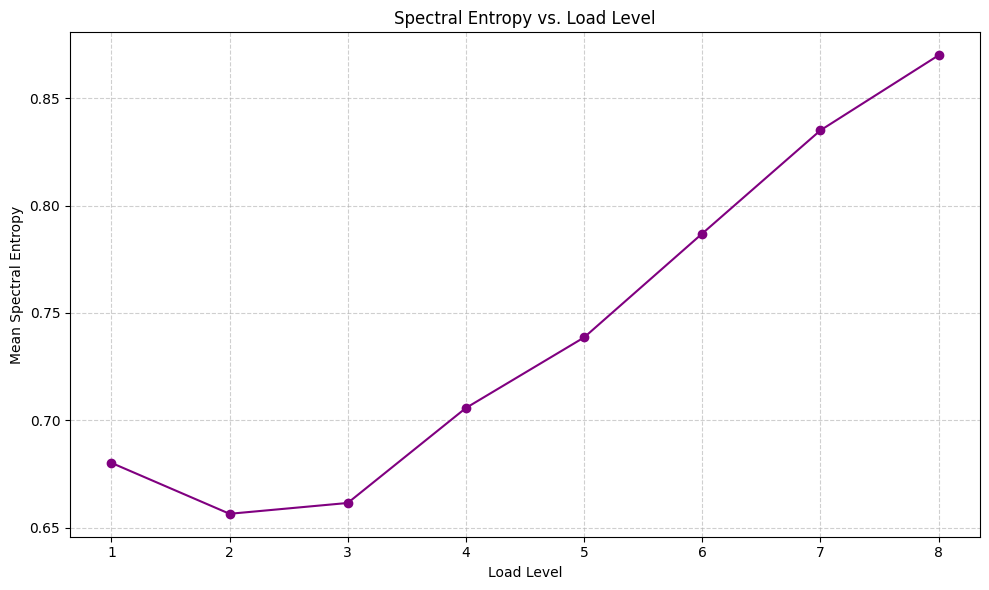

In [ ]:
print('Load | Spectral Entropy (mean across channels)')
print('-------------------------------------------')
spectral_entropies = []
for r in eeg_results:
    # Get EEG data and sampling frequency
    eeg_data = r['EEG']
    eeg_fs = r['EEG_fs']

    # Calculate band powers to get f and pxx
    _, f, pxx = band_powers(eeg_data, eeg_fs)

    # Calculate spectral entropy, averaging across channels
    # We calculate it for each channel and then take the mean
    channel_spectral_entropy = spectral_entropy(f, pxx)
    mean_spectral_entropy = np.mean(channel_spectral_entropy)
    spectral_entropies.append((r['load'], mean_spectral_entropy))
    print(f"{r['load']:<5}| {mean_spectral_entropy:.4f}")

# Optional: Plotting the spectral entropy vs load
loads = [s[0] for s in spectral_entropies]
entropies = [s[1] for s in spectral_entropies]

plt.figure(figsize=(10, 6))
plt.plot(loads, entropies, marker='o', linestyle='-', color='purple')
plt.title('Spectral Entropy vs. Load Level')
plt.xlabel('Load Level')
plt.ylabel('Mean Spectral Entropy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(loads)
plt.tight_layout()
plt.show()

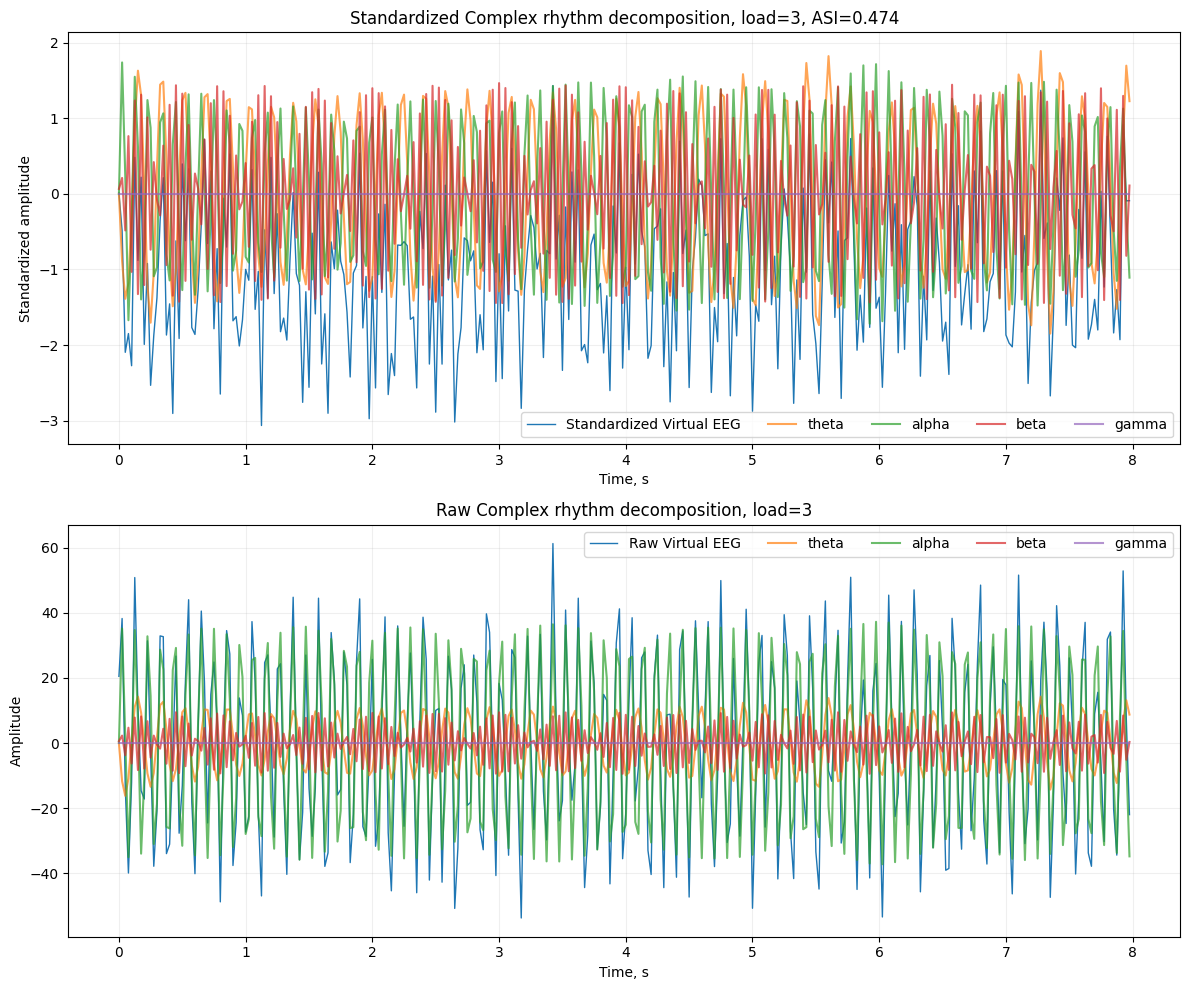

In [ ]:
def _raw_virtual_eeg(result, brain, fs_out=128.0, rhythm_params=None):
    """Generate a virtual EEG without the final standardization step."""
    defaults = dict(
        theta_base=0.34,
        theta_peak=0.34,
        theta_peak_load=2.5,
        theta_width=1.25,
        alpha_bg=10.0,
        alpha_target=40.0,
        beta_target=10.0,
        gamma_target=4.0,
        pac_strength=0.5,
        overload_noise=0.30,
        overload_sync=0.22,
        hr_weight=0.36,
        volume_conduction=0.10,
        theta_amp=20.0,
        beta_bg=1.5,
        gamma_bg=0.5,
        delta_amp=5.0
    )
    if rhythm_params: defaults.update(rhythm_params)
    p=defaults
    x=np.asarray(result['mean_x'],float); rate=np.asarray(result['spike_rate'],float)
    fs0=1.0/DT; step=max(1,int(round(fs0/fs_out))); fs=fs0/step
    x=x[::step]; rate=rate[::step]; t=np.arange(len(x))/fs
    n=len(brain.nodes); load=result['load']; targets=set(result['target_nodes'])
    rng=np.random.default_rng(SEED+1009*load)
    dx=np.gradient(x,axis=0)*fs
    hr=(0.82*x+0.05*dx+0.13*np.tanh(rate/4.0))
    hr=(hr-hr.mean(0))/(hr.std(0)+1e-6)
    eeg=p['hr_weight']*hr
    theta_amp=p['theta_base']+p['theta_peak']*np.exp(-((load-p['theta_peak_load'])/p['theta_width'])**2)
    overload=max(0.0,(load-4)/4.0)
    global_phase=rng.uniform(0,2*np.pi)
    for i in range(n):
        role=brain.roles[i]; target=i in targets
        phi=rng.uniform(0,2*np.pi)
        # realistic nonstationarity: slow amplitude modulation and slight frequency jitter
        theta_f=5.5+0.5*np.sin(2*np.pi*0.04*t+phi)
        theta_phase=2*np.pi*np.cumsum(theta_f)/fs + global_phase
        alpha_phase=2*np.pi*(9.5+0.25*np.sin(2*np.pi*0.03*t+phi))*t+phi
        beta_phase=2*np.pi*(18.0+0.8*np.sin(2*np.pi*0.05*t+phi))*t+0.7*phi
        gamma_phase=2*np.pi*(38.0+1.5*np.sin(2*np.pi*0.07*t+phi))*t+1.3*phi
        delta_phase = 2*np.pi*1.8*t + phi
        th=p['theta_amp']*(1.10 if role==0 else 0.92 if role==1 else 0.62)*np.sin(theta_phase)
        al=(p['alpha_target'] if target else p['alpha_bg'])*np.sin(alpha_phase)
        be=(p['beta_target'] if target else p['beta_bg'])*np.sin(beta_phase)
        gamma_env=(0.35+p['pac_strength']*(1+np.sin(theta_phase))/2.0)
        ga=(p['gamma_target'] if target else p['gamma_bg'])*gamma_env*np.sin(gamma_phase)
        de = p['delta_amp'] * np.sin(delta_phase)
        eeg[:,i]+=de+th+al+be+ga
    # overload creates common low-frequency interference and broadband noise
    if overload>0:
        common=np.sin(2*np.pi*6.2*t+global_phase)
        eeg += p['overload_sync']*overload*common[:,None]
        eeg += p['overload_noise']*overload*rng.standard_normal(eeg.shape)
    # weak volume conduction only; edges remain inferred from phase relations
    A=brain.adjacency.astype(float); row=A/(A.sum(1,keepdims=True)+1e-9)
    mix=(1-p['volume_conduction'])*np.eye(n)+p['volume_conduction']*row
    eeg=eeg@mix.T
    return eeg,fs

# Assuming brain, best_params, EEG_BANDS, and eeg_results are available from kernel state
# Use result from eeg_results for load=3 as an example
result_to_plot = eeg_results[2]
channel_idx = result_to_plot['target_nodes'][0]
seconds_to_plot = 8

# Get standardized EEG data from the result object
eeg_standardized = result_to_plot['EEG']
fs_standardized = result_to_plot['EEG_fs']
n_standardized = min(len(eeg_standardized), int(seconds_to_plot * fs_standardized))
t_standardized = np.arange(n_standardized) / fs_standardized

# Get raw EEG data using the custom helper function
eeg_raw, fs_raw = _raw_virtual_eeg(result_to_plot, brain, rhythm_params=best_params)
n_raw = min(len(eeg_raw), int(seconds_to_plot * fs_raw))
t_raw = np.arange(n_raw) / fs_raw

plt.figure(figsize=(12, 10))

# Subplot 1: Standardized EEG
plt.subplot(2, 1, 1)
plt.plot(t_standardized, eeg_standardized[:n_standardized, channel_idx], label='Standardized Virtual EEG', linewidth=1)
for b in ('theta', 'alpha', 'beta', 'gamma'):
    lo, hi = EEG_BANDS[b]
    y = _bandpass(eeg_standardized[:, [channel_idx]], fs_standardized, lo, hi)[:n_standardized, 0]
    # Standardize band-passed components for consistency with plot_rhythms
    y_norm = y / (np.std(y) + 1e-9)
    plt.plot(t_standardized, y_norm, alpha=.7, label=b)
plt.xlabel('Time, s')
plt.ylabel('Standardized amplitude')
plt.title(f"Standardized Complex rhythm decomposition, load={result_to_plot['load']}, ASI={result_to_plot['ASI']:.3f}")
plt.legend(ncol=5)
plt.grid(alpha=.2)

# Subplot 2: Raw EEG
plt.subplot(2, 1, 2)
plt.plot(t_raw, eeg_raw[:n_raw, channel_idx], label='Raw Virtual EEG', linewidth=1)
for b in ('theta', 'alpha', 'beta', 'gamma'):
    lo, hi = EEG_BANDS[b]
    y = _bandpass(eeg_raw[:, [channel_idx]], fs_raw, lo, hi)[:n_raw, 0]
    # Do not standardize band-passed components for raw EEG plot
    plt.plot(t_raw, y, alpha=.7, label=b)
plt.xlabel('Time, s')
plt.ylabel('Amplitude')
plt.title(f"Raw Complex rhythm decomposition, load={result_to_plot['load']}")
plt.legend(ncol=5)
plt.grid(alpha=.2)

plt.tight_layout()
plt.show()

## Attention Stability Index (ASI) Components Report

This report analyzes how different components contributing to the Attention Stability Index (ASI) change with increasing cognitive load. The components reflect various aspects of neural activity such as spectral engagement, alpha gating, phase organization, spatial selectivity, spectral complexity, temporal stability, and functional efficiency.

In [ ]:
import pandas as pd

# Prepare data for the report table
report_data = []
for r in eeg_results:
    load = r['load']
    asi = r['ASI']
    components = r['ASI_components']
    report_data.append({
        'Load': load,
        'ASI': f"{asi:.3f}",
        'Spectral Engagement': f"{components['spectral_engagement']:.3f}",
        'Alpha Gating': f"{components['alpha_gating']:.3f}",
        'Phase Organization': f"{components['phase_organization']:.3f}",
        'Spatial Selectivity': f"{components['spatial_selectivity']:.3f}",
        'Spectral Complexity': f"{components['spectral_complexity']:.3f}",
        'Temporal Stability': f"{components['temporal_stability']:.3f}",
        'Functional Efficiency': f"{components['functional_efficiency']:.3f}"
    })

df_report = pd.DataFrame(report_data)

# Display the table in markdown format
md_table = df_report.to_markdown(index=False)
print("### ASI Components per Load Level\n\n" + md_table)


### ASI Components per Load Level

|   Load |   ASI |   Spectral Engagement |   Alpha Gating |   Phase Organization |   Spatial Selectivity |   Spectral Complexity |   Temporal Stability |   Functional Efficiency |
|-------:|------:|----------------------:|---------------:|---------------------:|----------------------:|----------------------:|---------------------:|------------------------:|
|      1 | 0.45  |                 0.852 |          0.996 |                0.141 |                 0.997 |                 0.378 |                0.586 |                   0.044 |
|      2 | 0.498 |                 0.339 |          0.995 |                0.406 |                 0.996 |                 0.539 |                0.656 |                   0.05  |
|      3 | 0.474 |                 0.324 |          0.993 |                0.426 |                 0.996 |                 0.505 |                0.653 |                   0.027 |
|      4 | 0.449 |                 0.717 |          0.993 |      

### Visualization of Key ASI Components

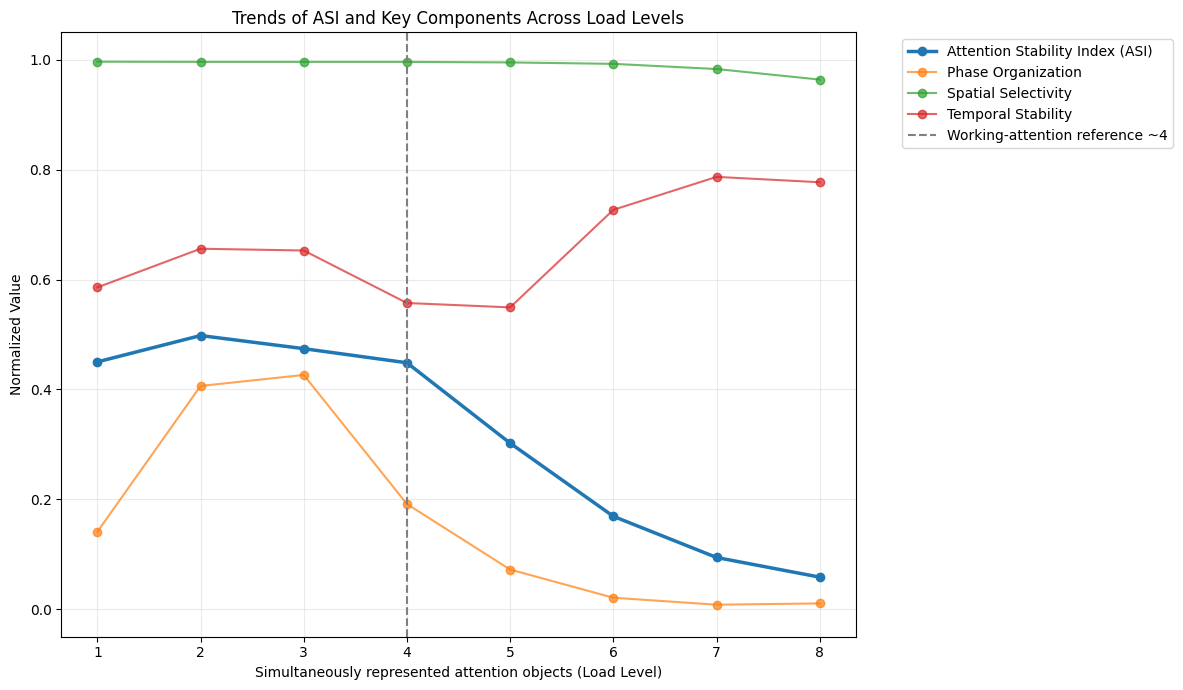

In [ ]:
import matplotlib.pyplot as plt

loads = [r['load'] for r in eeg_results]
asi = [r['ASI'] for r in eeg_results]
phase_organization = [r['ASI_components']['phase_organization'] for r in eeg_results]
spatial_selectivity = [r['ASI_components']['spatial_selectivity'] for r in eeg_results]
temporal_stability = [r['ASI_components']['temporal_stability'] for r in eeg_results]

plt.figure(figsize=(12, 7))
plt.plot(loads, asi, marker='o', linewidth=2.5, label='Attention Stability Index (ASI)')
plt.plot(loads, phase_organization, marker='o', alpha=0.7, label='Phase Organization')
plt.plot(loads, spatial_selectivity, marker='o', alpha=0.7, label='Spatial Selectivity')
plt.plot(loads, temporal_stability, marker='o', alpha=0.7, label='Temporal Stability')

plt.axvline(4, linestyle='--', color='gray', label='Working-attention reference ~4')
plt.xlabel('Simultaneously represented attention objects (Load Level)')
plt.ylabel('Normalized Value')
plt.title('Trends of ASI and Key Components Across Load Levels')
plt.ylim(-0.05, 1.05)
plt.grid(alpha=0.25)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Summary of Observations

- **Overall ASI:** The Attention Stability Index generally shows a peak at lower load levels and then declines as the load increases, indicating a decrease in attention stability with more simultaneous objects.
- **Phase Organization:** This component often plays a significant role in the overall ASI, reflecting the coordinated activity between different brain regions. Its trend with load can highlight how neural communication changes under cognitive strain.
- **Spatial Selectivity:** This measures the brain's ability to differentiate between target and non-target activity. A decline in spatial selectivity at higher loads suggests a breakdown in attentional focus.
- **Temporal Stability:** This component reflects the consistency of neural activity over time. As load increases, temporal stability may decrease, indicating more variable or erratic neural processing.